In [12]:
import sys
from pathlib import Path

project_src = Path(r"C:\CVEM\src")
if str(project_src) not in sys.path:
    sys.path.insert(0, str(project_src))

from object_detection_segmentation.make_masks import MakeMasks

In [13]:
#Converting all the images and json into masks and coco

mask_maker = MakeMasks(output_folder_name="masks")
saved_files = mask_maker.save_all_masks(
    output_format="png",
    save_npy=True,
    overwrite=True,
)

print(saved_files)

{'45f1c7df91.json': {'mask_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and json/masks/45f1c7df91_mask.png'), 'num_objects': 78, 'mask_shape': (512, 512), 'npy_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and json/masks/45f1c7df91_mask.npy')}, '6b35cd67c2.json': {'mask_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and json/masks/6b35cd67c2_mask.png'), 'num_objects': 23, 'mask_shape': (512, 512), 'npy_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and json/masks/6b35cd67c2_mask.npy')}, '8c7b437e1f.json': {'mask_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and json/masks/8c7b437e1f_mask.png'), 'num_objects': 66, 'mask_shape': (512, 512), 'npy_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and json/masks/8c7b437e1f_mask.npy')}, '8d6da13424.json': {'mask_path': WindowsPath('C:/CVEM/data/datasets/segmentation/Au_cube/all image and

Shape: (512, 512)
IDs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109]


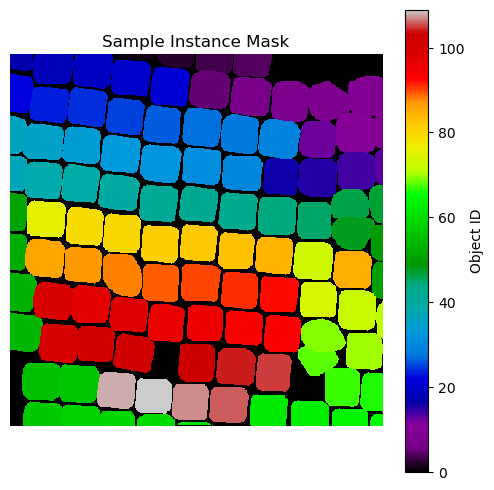

In [14]:
import numpy as np
#Inspect one example
data = mask_maker.load_anylabeling_json("95f1e903fb.json")
mask = mask_maker.create_instance_mask_from_json(data)

print("Shape:", mask.shape)
print("IDs:", np.unique(mask))

mask_maker.show_instance_mask(mask,title="Sample Instance Mask",)

In [15]:
# Build coco dataset for all images in separated coco files
for json_path in sorted(mask_maker.input_dir.glob("*.json")):
    coco_save_path = (
        mask_maker.mask_dir
        / f"{json_path.stem}_coco.json"
    )

    mask_maker.convert_one_json_to_coco(
        json_path=json_path,
        image_shape=(512, 512),
        category_name="Au cube",
        category_id=1,
        circle_points=36,
        save_path=coco_save_path,
    )

    print("Saved:", coco_save_path)

Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\45f1c7df91_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\6b35cd67c2_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\8c7b437e1f_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\8d6da13424_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\95f1e903fb_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\a1ad693992_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\coco_annotations_coco.json
Saved: C:\CVEM\data\datasets\segmentation\Au_cube\all image and json\masks\d21b68e1be_coco.json


In [16]:
# Build coco dataset for all images in one coco file
coco_dataset = mask_maker.save_all_as_coco(
    category_name="Au cube",
    category_id=1,
    image_extension=".png",
    circle_points=36,
)

print("Images:", len(coco_dataset["images"]))
print("Annotations:", len(coco_dataset["annotations"]))

Images: 8
Annotations: 459
